**Contexte**

Une entreprise dispose de données provenant de plusieurs bâtiments équipés de capteurs. Pour chaque observation, on dispose par exemple de la température moyenne, de l’humidité, du nombre d'occupants, de l’heure, du jour de la semaine, de la surface du bâtiment et de la consommation énergétique. L'objectif de l’atelier est de construire avec TensorFlow/Keras un réseau de neurones capable de prédire la consommation énergétique d'un bâtiment à partir de caractéristiques telles que température, humidité et nombre d'occupants.

**Partie 0 – mise en place de l’environnement**

Alors la structure du projet est déja fais la création du notebook donc nous allons a la troisiéme question qui est l'installation des bibliothéques et leurs importations

3) Installer et importer tensorflow, matplotlib et numpy

In [2]:
!pip install tensorflow
!pip install matplotlib
!pip install numpy

In [4]:
# import des bibliothéques

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("importation terminée")


importation terminée


**Partie 1 – Génération du dataset**

1) Générer aléatoirement 1000 valeurs pour chacune des variables suivantes :

a) temperature : valeurs qui suivent une loi normale avec une moyenne de 25 °C et un
écart-type de 4 °C.

In [22]:
# alors ici on utilise la loi normale avec une moyenne de 25 (loc) et un écart-type de 4 (scale) et une size de 1000
#donc on vas utiliser la syntaxe random.normale()

n=1000
temperature = tf.random.normal(shape=(1000,) , mean=25 , stddev=4 )
temperature.shape
print(tf.round(temperature[:10] * 100)/100)



tf.Tensor([27.3  25.73 20.88 20.58 25.02 25.26 21.31 17.92 25.9  20.31], shape=(10,), dtype=float32)


b) humidite : valeurs réparties de façon uniforme entre 30 % et 80 %.

In [23]:
humidite = tf.random.uniform(shape=(1000,) , minval=30 , maxval=80)
print(tf.round(humidite[:10] * 100)/100)

tf.Tensor([66.13 70.94 36.12 74.78 53.88 55.31 69.09 32.18 31.4  71.33], shape=(10,), dtype=float32)


c) occupants : valeurs entières choisies entre 1 et 49 inclus.

In [25]:
# c'est une valeur entier choisie entre 1 et 49 on utilise on ajoute le type que est un entier ici

occupants = tf.random.uniform(shape=(1000,), minval=1, maxval=50, dtype=tf.int32)

print(occupants[:10].numpy())


[25 41 40 19 34 33 29 17  2 44]


2) Déterminer la variable consommation avec la formule suivante :

a) la consommation de base (0 °C, pas d'humidité et pièce vide) est de 50

La formule donnée par l'énoncé est **linéaire** (chaque variable contribue indépendamment et de
façon proportionnelle à la consommation) :

$$
\text{consommation} = 50 \;+\; 5 \times \text{temperature} \;+\; 1{,}5 \times \text{humidite}
\;+\; 4 \times \text{occupants} \;+\; \varepsilon
$$

où :
- **50** : la consommation de base incompressible (0 °C, 0 % d'humidité, pièce vide) ;
- **5 × température** : chaque degré supplémentaire coûte 5 unités (chauffage/climatisation) ;
- **1,5 × humidité** : chaque point d'humidité en plus coûte 1,5 unité (déshumidification) ;
- **4 × occupants** : chaque personne présente coûte 4 unités (éclairage, appareils, etc.) ;
- **ε (bruit)** : un terme aléatoire `~ N(0, 10)` (généré ici aussi avec `tf.random.normal`) qui simule tous les facteurs non mesurés
  (isolation du bâtiment, appareils allumés par hasard, courants d'air...). Sans ce bruit, la
  relation serait **parfaitement linéaire** et un simple réseau à un seul neurone (voire une
  régression linéaire) suffirait à obtenir une erreur nulle : le bruit rend le problème réaliste et
  justifie l'usage d'un modèle capable d'apprendre malgré l'incertitude.

In [26]:
n=1000
bruit = tf.random.normal(shape=(n,), mean=0, stddev=10)

# occupants est en int32 : on le convertit en float32 avant de l'utiliser dans un calcul
# avec des tenseurs float32 (temperature, humidite, bruit), sinon TensorFlow lève une erreur
# de type (contrairement à NumPy, TensorFlow ne convertit jamais les types implicitement).
occupants_float = tf.cast(occupants, tf.float32)

consommation = (
    50
    + 5 * temperature
    + 1.5 * humidite
    + 4 * occupants_float
    + bruit
)

print("dtype de consommation :", consommation.dtype)
print("\nAperçu des 10 premières valeurs de consommation :")
print(tf.round(consommation[:10] * 100) / 100)
print(f"\nConsommation moyenne : {tf.reduce_mean(consommation):.2f}")
print(f"Consommation min/max : {tf.reduce_min(consommation):.2f} / {tf.reduce_max(consommation):.2f}")


dtype de consommation : <dtype: 'float32'>

Aperçu des 10 premières valeurs de consommation :
tf.Tensor([396.29 438.44 369.09 334.1  398.91 388.53 378.35 259.97 234.36 447.43], shape=(10,), dtype=float32)

Consommation moyenne : 359.72
Consommation min/max : 193.37 / 512.88


3) Rassembler les variables (temperature, humidite et occupants) dans la matrice des
caractéristiques (features) X de taille 1000x3 en convertissant éventuellement les données au
format (float32) optimisé pour les calculs

Un réseau de neurones Keras attend en entrée une **matrice 2D** de forme
`(nombre d'observations, nombre de caractéristiques)`, ici `(1000, 3)`. Avec des tenseurs
TensorFlow, on empile `temperature`, `humidite` et `occupants_float` **en colonnes** avec
`tf.stack(..., axis=1)` (l'équivalent, côté TensorFlow, de `np.column_stack`) : chaque tenseur 1D
de forme `(1000,)` devient une colonne du tenseur 2D résultant.

On s'assure que le résultat est bien en **`float32`** (type déjà utilisé par tous les tenseurs
générés, sauf `occupants` qu'on convertit d'abord) car c'est :
- le type de données **par défaut utilisé en interne par TensorFlow/Keras** pour les poids et les
  calculs ;
- deux fois plus économe en mémoire que le `float64` ;
- **optimisé pour le calcul sur GPU**, généralement bien plus rapide en 32 bits.

In [27]:
X = tf.stack([temperature, humidite, occupants_float], axis=1)

print("Forme de X :", X.shape)
print("dtype de X :", X.dtype)
print("\nAperçu des 5 premières lignes de X (colonnes : temperature, humidite, occupants) :")
print(X[:5].numpy()) # comme on l'as vue dans le veille .numpy permet d'avoir le résultat format tableau numpy


Forme de X : (1000, 3)
dtype de X : <dtype: 'float32'>

Aperçu des 5 premières lignes de X (colonnes : temperature, humidite, occupants) :
[[27.30032  66.13454  25.      ]
 [25.733604 70.93983  41.      ]
 [20.876245 36.118126 40.      ]
 [20.578606 74.780426 19.      ]
 [25.018553 53.876625 34.      ]]


4) Créer la cible (target) y qui contiendra la variable consommation, au format float32

Alors nous avnons déja
`consommation` comme tenseur TensorFlow en `float32` (Partie 1.2) : on peut l'utiliser directement comme cible `y`, sans conversion supplémentaire. On le laisse en **vecteur 1D** de
forme `(1000,)` : c'est le format attendu par Keras pour une sortie de régression à une seule valeur (Keras se charge en interne de le mettre en forme `(batch, 1)` face à la couche de sortie).

In [28]:
y = consommation

print("Forme de y :", y.shape)
print("dtype de y :", y.dtype)
print("\nAperçu des 5 premières valeurs de y :")
print(y[:5].numpy())


Forme de y : (1000,)
dtype de y : <dtype: 'float32'>

Aperçu des 5 premières valeurs de y :
[396.29373 438.44434 369.08948 334.09714 398.9134 ]


**Partie 2 – Découpage Train/Test**

Diviser le dataset précédent (X et y) en deux ensembles distincts : un pour l'entraînement (train)
et un pour le test (test). Avec les conditions suivantes : 20% des données serviront au test ; garantir
la reproductibilité du découpage.

In [31]:
from sklearn.model_selection import train_test_split


# d'abord faut savoir que train_test_split attend des tableaux numpy pas des tenseurs donc nous allons convertir les
# feature en tableau et les targets en tableau aussi

X_np = X.numpy()
y_np = y.numpy()

# decoupage des données en donnée test(20%) et donnée train(80%)
X_train , X_test , y_train ,y_test = train_test_split(
    X_np,
    y_np,
    test_size=0.2, # qui correspond à 20 % des données
    random_state=42
)

print("taille de X_train",X_train.shape)
print("taille de X_test",X_test.shape)
print("taille de y_train",y_train.shape)
print("taille de y_test",y_test.shape)


taille de X_train (800, 3)
taille de X_test (200, 3)
taille de y_train (800,)
taille de y_test (200,)


**Partie 3 – Création du modèle**

1) Construire un réseau de neurones qui utilise l’architecture séquentielle suivante :

                 a) couche 1 : 16 neurones avec relu comme fonction d’activation

                  b) couche 2 : 8 neurones avec relu

                  c) couche 3 : 1 seul neurone.

In [34]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(3,)),                    # 3 caractéristiques en entrée
    layers.Dense(16, activation="relu", name="couche_cachee_1"),
    layers.Dense(8, activation="relu", name="couche_cachee_2"),
    layers.Dense(1, name="couche_sortie")          # 1 neurone, pas d'activation -> régression
])

### 2) Résumé textuel de l'architecture

`model.summary()` affiche, pour chaque couche : son nom, sa forme de sortie et son **nombre de
paramètres** (poids + biais). Cela permet de vérifier visuellement que l'architecture correspond
bien à ce qui était voulu avant même de lancer l'entraînement.

In [35]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ couche_cachee_1 (Dense)         │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_cachee_2 (Dense)         │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_sortie (Dense)           │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

**Partie 4 – Compilation du modèle**

Compiler le modèle avec une méthode pour ajuster les poids, une fonction permettant de mesurer
l'erreur de prédiction et une métrique permettant de suivre l'erreur absolue moyenne.

In [37]:
# alors pour compiler le model on appelle model.compile qui prend en paramétre:
# l'optimizer qui est la méthode qui ajuste les poids du réseau à chaque étape pour réduire les erreurs (param obligatoire)
# le loss qui est la fonction qui mesure l'erreur de prediction que l'optimizer cherche à minimiser (param obligatoire)
# le metric qui est supplémentaire (n'est pas obligatoire comme paramétre) sert pour la compréhension humaine

model.compile(
    optimizer="adam",         # méthode d'ajustement des poids
    loss="mse",                # fonction de perte : erreur quadratique moyenne (régression)
    metrics=["mae"]            # métrique de suivi : erreur absolue moyenne
)

print("compilation terminée")

compilation terminée


**Partie 5 – Entraînement du modèle**

1) Entrainer le modèle avec 20 % des données d'entraînement utilisés pour la validation, 50
passages sur les données et 16 observations traitées à la fois. Sauvegarder, dans la variable
history, l'historique de l’entraînement

In [39]:
#Alors on nous as donnée 20% des données d'entrainement utilisés pour la validation qui sera définit avec validation_split
# 50 passages sur les données qui correspond à l'époch et 16 observations traitées à la fois qui correspond au batch définie par batch_size
history = model.fit(
    X_train, y_train,
    validation_split=0.2,   # 20 % du train utilisés pour la validation
    epochs=50,                # 50 passages complets sur les données
    batch_size=16,             # 16 observations traitées à la fois
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 143.8513 - mae: 9.7379 - val_loss: 150.8185 - val_mae: 9.7453
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 143.5836 - mae: 9.7327 - val_loss: 146.9491 - val_mae: 9.6776
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 141.9854 - mae: 9.7318 - val_loss: 147.5569 - val_mae: 9.6850
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 141.8104 - mae: 9.6828 - val_loss: 147.0878 - val_mae: 9.6775
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 141.9839 - mae: 9.7206 - val_loss: 149.7385 - val_mae: 9.7136
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 142.9463 - mae: 9.7077 - val_loss: 151.4865 - val_mae: 9.7631
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 143.7995 - mae: 9.7521 - val_loss: 147.7565 - val_mae: 9.6768
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 141.2883 - mae: 9.6846 - val_loss: 148.6240 - val_mae: 9.6834
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s

2) Examiner le contenu de history

In [40]:
# history.history est un dictionnaire dont les clés sont les noms des métriques suivies
# (loss, mae pour le train, et leurs équivalents val_loss, val_mae pour la validation), et les
# valeurs sont des listes contenant la valeur de la métrique à chaque epoch.
print("Clés disponibles dans history.history :", list(history.history.keys()))
print("\nNombre de valeurs par clé (doit être égal au nombre d'epochs) :",
      len(history.history["loss"]))

print("\nLoss (MSE) des 5 premières epochs :", np.round(history.history["loss"][:5], 2))
print("Loss (MSE) des 5 dernières epochs  :", np.round(history.history["loss"][-5:], 2))

Clés disponibles dans history.history : ['loss', 'mae', 'val_loss', 'val_mae']

Nombre de valeurs par clé (doit être égal au nombre d'epochs) : 50

Loss (MSE) des 5 premières epochs : [143.85 143.58 141.99 141.81 141.98]
Loss (MSE) des 5 dernières epochs  : [138.47 138.49 142.3  137.29 140.33]


3) Se servir de l’historique pour visualiser (graphique) et interpréter l’apprentissage

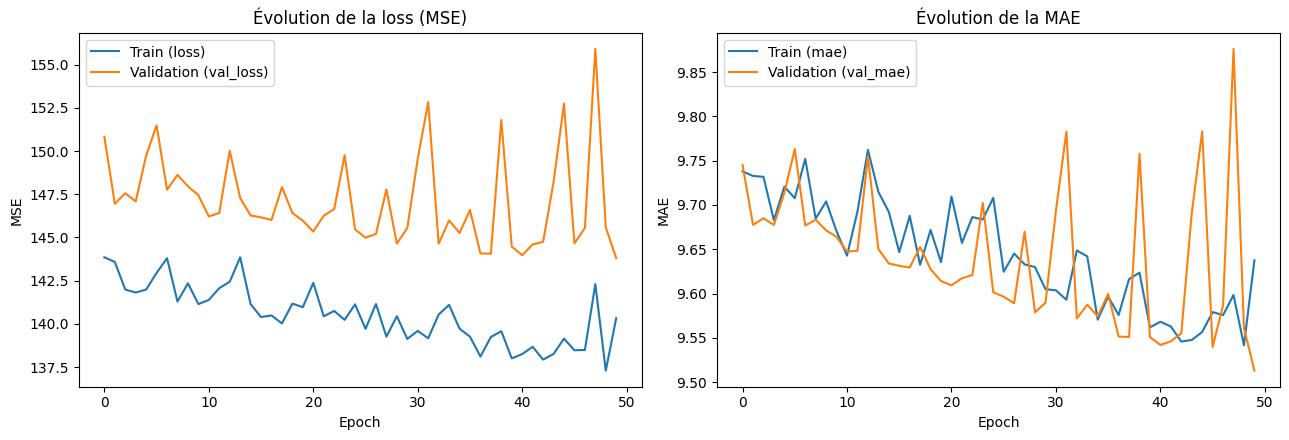

In [41]:
# Alors nous allons visualiser l'évolution de la loss (MSE) et l'évolution de la MAE de l'epoch
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history.history["loss"], label="Train (loss)")
axes[0].plot(history.history["val_loss"], label="Validation (val_loss)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Évolution de la loss (MSE)")
axes[0].legend()

axes[1].plot(history.history["mae"], label="Train (mae)")
axes[1].plot(history.history["val_mae"], label="Validation (val_mae)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].set_title("Évolution de la MAE")
axes[1].legend()

plt.tight_layout()
plt.show()


**Partie 6 – Evaluation**

1) Evaluer le modèle sur les données de test pour récupérer la fonction de perte et la métrique
cible

In [42]:
# model.evaluate permet d'évaluer le modéle sur des données qu'il n'a jamais vue ni pendant l'entrainement ni pendant la validation
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print(f"MSE sur le jeu de test : {test_loss:.2f}")
print(f"MAE sur le jeu de test : {test_mae:.2f}")


MSE sur le jeu de test : 153.23
MAE sur le jeu de test : 10.02


2) Interprétation des résultats obtenus

- La **MSE** est exprimée dans l'unité de la cible **au carré** (ici, « consommation² »), ce qui la
  rend peu intuitive à interpréter directement — elle sert surtout de fonction à minimiser pendant
  l'entraînement.
- La **MAE**, en revanche, s'exprime dans la **même unité que la consommation** : une MAE de, par
  exemple, `8` signifie qu'**en moyenne, le modèle se trompe de 8 unités de consommation** par
  rapport à la vraie valeur. On peut mettre ce chiffre en perspective en le comparant à l'écart-type
  du bruit ajouté à la génération des données (`10`, Partie 1) : une MAE proche de ce niveau indique
  que le modèle a appris **la meilleure prédiction possible compte tenu du bruit irréductible**
  présent dans les données — il ne peut, par construction, pas faire beaucoup mieux.
- On peut aussi comparer la MAE à l'échelle moyenne de la consommation (calculée en Partie 1) pour
  juger si l'erreur relative est faible ou élevée.

**Partie 7 – Prédiction**

1) Faire des prédictions avec les données de test

In [48]:
y_pred = model.predict(X_test, verbose=0).flatten()   # flatten : (200,1) à (200,) pour comparer à y_test

print("Aperçu des 10 premières prédictions :")
print(np.round(y_pred[:10], 2))

Aperçu des 10 premières prédictions :
[300.95 436.22 417.16 280.69 318.35 312.43 461.6  242.81 220.29 354.33]


2) Comparer les prédictions avec les valeurs réelles

In [50]:
import pandas as pd

# pour l'afficher sous forme de dataframme
comparaison = pd.DataFrame({
    "valeur_reelle": y_test,
    "prediction": y_pred,
    "erreur_absolue": np.abs(y_test - y_pred)
})

comparaison.head(15)

,valeur_reelle,prediction,erreur_absolue
0,311.891815,300.954529,10.937286
1,428.537384,436.215820,7.678436
2,422.835724,417.158478,5.677246
3,297.180847,280.690125,16.490723
4,303.789490,318.354980,14.565491
5,326.507416,312.434631,14.072784
6,475.204529,461.600464,13.604065
7,255.079453,242.811127,12.268326
8,226.190765,220.289917,5.900848
9,339.077698,354.328888,15.251190


3) Visualiser et interpréter cette comparaison. Que devrait-on observer si le modèle était parfait ?

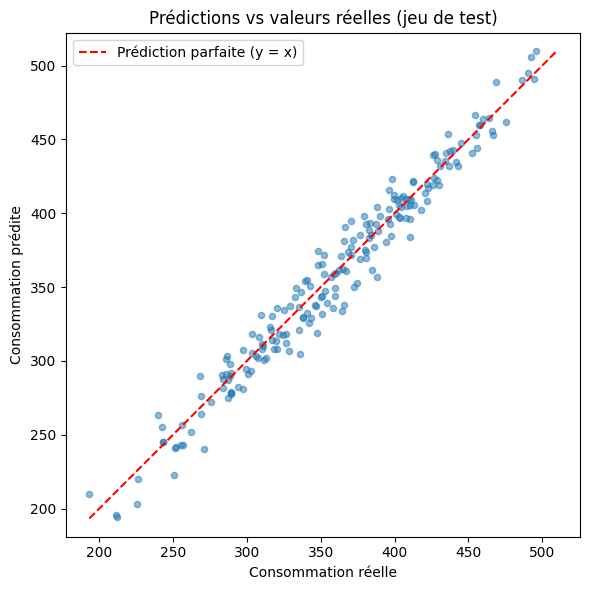

In [51]:
# Pour la visualisation nous allons traçer un nuage de point  entre valeurs réelles et valeurs prédites
#avec en plus la droite y=x (qui correspond à la prediction réelle)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=20)

# Droite y = x : ce que donnerait un modèle parfait
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Prédiction parfaite (y = x)")

plt.xlabel("Consommation réelle")
plt.ylabel("Consommation prédite")
plt.title("Prédictions vs valeurs réelles")
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.show()


**Que devrait-on observer si le modèle était parfait ?**

Si le modèle prédisait la consommation **sans aucune erreur**, tous les points seraient
**exactement alignés sur la droite rouge `y = x`** (prédiction = réalité pour chaque observation).

Ici, comme les données contiennent un **bruit aléatoire irréductible** (ajouté volontairement en
Partie 1, `~N(0, 10)`), on observe un nuage de points **serré autour de la diagonale mais pas
parfaitement aligné dessus** : c'est le comportement attendu et souhaitable — un modèle dont les
points seraient parfaitement sur la droite aurait en réalité **appris le bruit** (sur-apprentissage
sur les données d'entraînement), ce qui ne serait pas reproductible sur de nouvelles données.